###### 132_4_light_review_period_filter.ipynb

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False

In [3]:
df = pd.read_csv("dataset/lcm_period_light_review.csv",
                 encoding="utf-8-sig",)

In [4]:
df

,defect_id,site,model,defect_category,defect_qty,occ_at_jst,status
0,D001,SUS,J69P,Buck-IC,3,2026-06-30 23:50:00+09:00,回答済
1,D002,WSE,310D,Coil,1,2026-07-01 00:10:00+09:00,回答済
2,D003,GSE,310D,NTF,1,2026-07-01 09:30:00+09:00,回答済
3,D004,META,J69P,Buck-IC,2,2026-07-02 14:20:00+09:00,調査中
4,D005,MEAX,36WA,Coil,4,2026-07-03 18:45:00+09:00,回答済
5,D006,MELAC,3BVT,NTF,1,2026-07-04 08:15:00+09:00,回答済
6,D007,SUS,36WA,Buck-IC,5,2026-07-05 22:10:00+09:00,回答済
7,D008,WSE,J69P,Coil,2,2026-07-06 01:30:00+09:00,調査中
8,D009,GSE,310D,Coil,3,2026-07-07 11:40:00+09:00,回答済
9,D010,META,36WA,Buck-IC,2,2026-07-08 00:00:00+09:00,回答済


In [5]:
df.dtypes

defect_id            str
site                 str
model                str
defect_category      str
defect_qty         int64
occ_at_jst           str
status               str
dtype: object

In [7]:
df["defect_qty_num"] = pd.to_numeric(
    df["defect_qty"],
    errors="coerce",
)
df.dtypes

defect_id            str
site                 str
model                str
defect_category      str
defect_qty         int64
occ_at_jst           str
status               str
defect_qty_num     int64
dtype: object

In [8]:
df["defect_qty_calc"] = (
    df["defect_qty_num"]
    .fillna(0)
    .astype(int)
)
df.dtypes

defect_id            str
site                 str
model                str
defect_category      str
defect_qty         int64
occ_at_jst           str
status               str
defect_qty_num     int64
defect_qty_calc    int64
dtype: object

In [9]:
df

,defect_id,site,model,defect_category,defect_qty,occ_at_jst,status,defect_qty_num,defect_qty_calc
0,D001,SUS,J69P,Buck-IC,3,2026-06-30 23:50:00+09:00,回答済,3,3
1,D002,WSE,310D,Coil,1,2026-07-01 00:10:00+09:00,回答済,1,1
2,D003,GSE,310D,NTF,1,2026-07-01 09:30:00+09:00,回答済,1,1
3,D004,META,J69P,Buck-IC,2,2026-07-02 14:20:00+09:00,調査中,2,2
4,D005,MEAX,36WA,Coil,4,2026-07-03 18:45:00+09:00,回答済,4,4
5,D006,MELAC,3BVT,NTF,1,2026-07-04 08:15:00+09:00,回答済,1,1
6,D007,SUS,36WA,Buck-IC,5,2026-07-05 22:10:00+09:00,回答済,5,5
7,D008,WSE,J69P,Coil,2,2026-07-06 01:30:00+09:00,調査中,2,2
8,D009,GSE,310D,Coil,3,2026-07-07 11:40:00+09:00,回答済,3,3
9,D010,META,36WA,Buck-IC,2,2026-07-08 00:00:00+09:00,回答済,2,2


In [10]:
df.columns

Index(['defect_id', 'site', 'model', 'defect_category', 'defect_qty',
       'occ_at_jst', 'status', 'defect_qty_num', 'defect_qty_calc'],
      dtype='str')

In [11]:
df.dtypes

defect_id            str
site                 str
model                str
defect_category      str
defect_qty         int64
occ_at_jst           str
status               str
defect_qty_num     int64
defect_qty_calc    int64
dtype: object

In [12]:
df["occ_at_jst_raw"] = df["occ_at_jst"]

In [13]:
df[
    [
        "occ_at_jst",
        "occ_at_jst_raw",
    ]
]

,occ_at_jst,occ_at_jst_raw
0,2026-06-30 23:50:00+09:00,2026-06-30 23:50:00+09:00
1,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00
2,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00
3,2026-07-02 14:20:00+09:00,2026-07-02 14:20:00+09:00
4,2026-07-03 18:45:00+09:00,2026-07-03 18:45:00+09:00
5,2026-07-04 08:15:00+09:00,2026-07-04 08:15:00+09:00
6,2026-07-05 22:10:00+09:00,2026-07-05 22:10:00+09:00
7,2026-07-06 01:30:00+09:00,2026-07-06 01:30:00+09:00
8,2026-07-07 11:40:00+09:00,2026-07-07 11:40:00+09:00
9,2026-07-08 00:00:00+09:00,2026-07-08 00:00:00+09:00


In [14]:
df["occ_at_jst_clean"] = (
    df["occ_at_jst"]
    .astype(str)
    .str.strip()
)

In [16]:
df[
    [
        "occ_at_jst",
        "occ_at_jst_clean"
    ]
].dtypes

occ_at_jst          str
occ_at_jst_clean    str
dtype: object

In [17]:
df["occ_at_jst_dt"] = pd.to_datetime(
    df["occ_at_jst_clean"],
    errors="coerce",
)

In [18]:
df[
    [
        "occ_at_jst_clean",
        "occ_at_jst_dt",
    ]
].dtypes

occ_at_jst_clean                          str
occ_at_jst_dt       datetime64[us, UTC+09:00]
dtype: object

In [19]:
df_date_ng = df[
    df["occ_at_jst_dt"].isna()
].copy()

df_date_ng

,defect_id,site,model,defect_category,defect_qty,occ_at_jst,status,defect_qty_num,defect_qty_calc,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
10,D011,MEAX,310D,Coil,1,NaN,未回答,1,1,NaN,NaN,NaT
11,D012,MELAC,J69P,NTF,1,日付不正,調査中,1,1,日付不正,日付不正,NaT


In [20]:
df_work = df[
    df["occ_at_jst_dt"].notna()
].copy()
df_work

,defect_id,site,model,defect_category,defect_qty,occ_at_jst,status,defect_qty_num,defect_qty_calc,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
0,D001,SUS,J69P,Buck-IC,3,2026-06-30 23:50:00+09:00,回答済,3,3,2026-06-30 23:50:00+09:00,2026-06-30 23:50:00+09:00,2026-06-30 23:50:00+09:00
1,D002,WSE,310D,Coil,1,2026-07-01 00:10:00+09:00,回答済,1,1,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00
2,D003,GSE,310D,NTF,1,2026-07-01 09:30:00+09:00,回答済,1,1,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00
3,D004,META,J69P,Buck-IC,2,2026-07-02 14:20:00+09:00,調査中,2,2,2026-07-02 14:20:00+09:00,2026-07-02 14:20:00+09:00,2026-07-02 14:20:00+09:00
4,D005,MEAX,36WA,Coil,4,2026-07-03 18:45:00+09:00,回答済,4,4,2026-07-03 18:45:00+09:00,2026-07-03 18:45:00+09:00,2026-07-03 18:45:00+09:00
5,D006,MELAC,3BVT,NTF,1,2026-07-04 08:15:00+09:00,回答済,1,1,2026-07-04 08:15:00+09:00,2026-07-04 08:15:00+09:00,2026-07-04 08:15:00+09:00
6,D007,SUS,36WA,Buck-IC,5,2026-07-05 22:10:00+09:00,回答済,5,5,2026-07-05 22:10:00+09:00,2026-07-05 22:10:00+09:00,2026-07-05 22:10:00+09:00
7,D008,WSE,J69P,Coil,2,2026-07-06 01:30:00+09:00,調査中,2,2,2026-07-06 01:30:00+09:00,2026-07-06 01:30:00+09:00,2026-07-06 01:30:00+09:00
8,D009,GSE,310D,Coil,3,2026-07-07 11:40:00+09:00,回答済,3,3,2026-07-07 11:40:00+09:00,2026-07-07 11:40:00+09:00,2026-07-07 11:40:00+09:00
9,D010,META,36WA,Buck-IC,2,2026-07-08 00:00:00+09:00,回答済,2,2,2026-07-08 00:00:00+09:00,2026-07-08 00:00:00+09:00,2026-07-08 00:00:00+09:00


In [22]:
start_date = pd.Timestamp(
    "2026-07-01 00:00:00",
    tz="Asia/Tokyo",
)

In [25]:
end_date = pd.Timestamp(
    "2026-07-08 00:00:00",
    tz="Asia/Tokyo",
)

In [26]:
start_date, end_date

(Timestamp('2026-07-01 00:00:00+0900', tz='Asia/Tokyo'),
 Timestamp('2026-07-08 00:00:00+0900', tz='Asia/Tokyo'))

In [28]:
df_period = df_work[
    (df_work["occ_at_jst_dt"] >= start_date)
    & (df_work["occ_at_jst_dt"] < end_date)
].copy()
df_period

,defect_id,site,model,defect_category,defect_qty,occ_at_jst,status,defect_qty_num,defect_qty_calc,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
1,D002,WSE,310D,Coil,1,2026-07-01 00:10:00+09:00,回答済,1,1,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00
2,D003,GSE,310D,NTF,1,2026-07-01 09:30:00+09:00,回答済,1,1,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00
3,D004,META,J69P,Buck-IC,2,2026-07-02 14:20:00+09:00,調査中,2,2,2026-07-02 14:20:00+09:00,2026-07-02 14:20:00+09:00,2026-07-02 14:20:00+09:00
4,D005,MEAX,36WA,Coil,4,2026-07-03 18:45:00+09:00,回答済,4,4,2026-07-03 18:45:00+09:00,2026-07-03 18:45:00+09:00,2026-07-03 18:45:00+09:00
5,D006,MELAC,3BVT,NTF,1,2026-07-04 08:15:00+09:00,回答済,1,1,2026-07-04 08:15:00+09:00,2026-07-04 08:15:00+09:00,2026-07-04 08:15:00+09:00
6,D007,SUS,36WA,Buck-IC,5,2026-07-05 22:10:00+09:00,回答済,5,5,2026-07-05 22:10:00+09:00,2026-07-05 22:10:00+09:00,2026-07-05 22:10:00+09:00
7,D008,WSE,J69P,Coil,2,2026-07-06 01:30:00+09:00,調査中,2,2,2026-07-06 01:30:00+09:00,2026-07-06 01:30:00+09:00,2026-07-06 01:30:00+09:00
8,D009,GSE,310D,Coil,3,2026-07-07 11:40:00+09:00,回答済,3,3,2026-07-07 11:40:00+09:00,2026-07-07 11:40:00+09:00,2026-07-07 11:40:00+09:00


In [29]:
df_period.head(3)

,defect_id,site,model,defect_category,defect_qty,occ_at_jst,status,defect_qty_num,defect_qty_calc,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
1,D002,WSE,310D,Coil,1,2026-07-01 00:10:00+09:00,回答済,1,1,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00
2,D003,GSE,310D,NTF,1,2026-07-01 09:30:00+09:00,回答済,1,1,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00
3,D004,META,J69P,Buck-IC,2,2026-07-02 14:20:00+09:00,調査中,2,2,2026-07-02 14:20:00+09:00,2026-07-02 14:20:00+09:00,2026-07-02 14:20:00+09:00


In [30]:
df_site_summary = df_period.groupby(
    "site",
    as_index=False
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_calc", "sum"),
)

df_site_summary


,site,defect_count,defect_qty_sum
0,GSE,2,4
1,MEAX,1,4
2,MELAC,1,1
3,META,1,2
4,SUS,1,5
5,WSE,2,3


In [31]:
df_site_summary = df_site_summary.sort_values(
    [
        "defect_qty_sum",
        "site",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(drop=True)
df_site_summary

,site,defect_count,defect_qty_sum
0,SUS,1,5
1,GSE,2,4
2,MEAX,1,4
3,WSE,2,3
4,META,1,2
5,MELAC,1,1


In [32]:
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

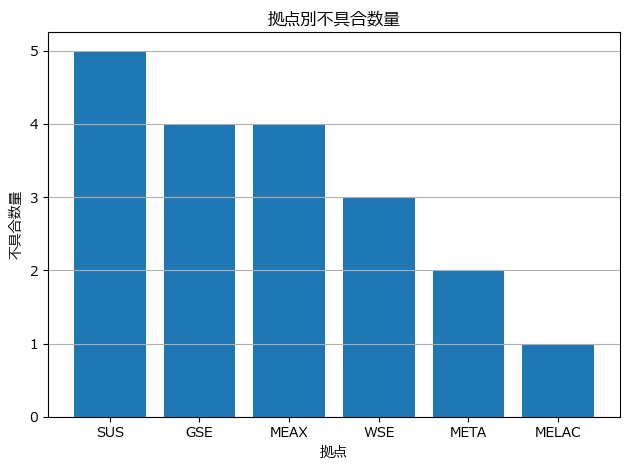

In [37]:
plt.bar(
    df_site_summary["site"],
    df_site_summary["defect_qty_sum"],
)

plt.title("拠点別不具合数量")
plt.xlabel("拠点")
plt.ylabel("不具合数量")

plt.grid(axis="y")
plt.tight_layout()

plt.show()